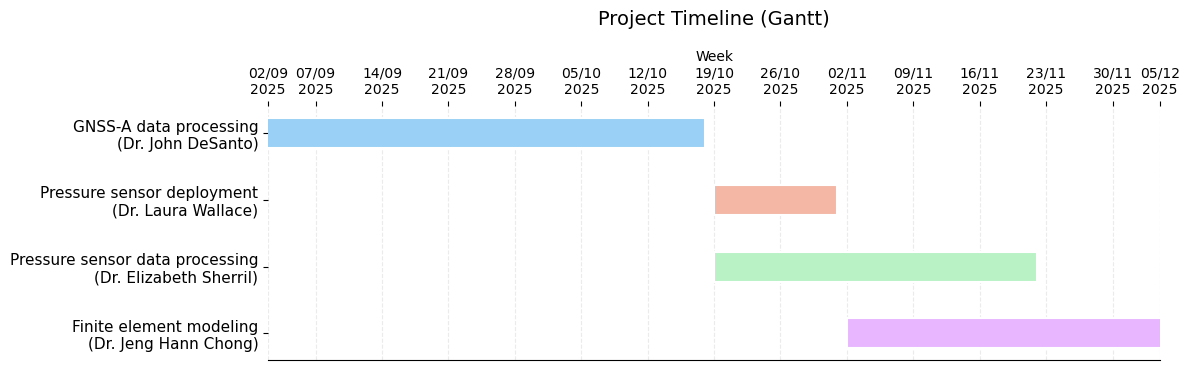

In [2]:
from io import StringIO
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================
# DATA
# =========================
data = """Task,Key person,Start,End,Color
GNSS-A data processing,Dr. John DeSanto,2025-09-01,2025-10-18,#9ad0f5
Pressure sensor deployment,Dr. Laura Wallace,2025-10-19,2025-11-01,#f4b7a6
Pressure sensor data processing,Dr. Elizabeth Sherril,2025-10-19,2025-11-22,#b8f2c5
Finite element modeling,Dr. Jeng Hann Chong,2025-11-02,2025-12-06,#e7b6ff
"""

df = pd.read_csv(StringIO(data))
df["Start"] = pd.to_datetime(df["Start"])
df["End"] = pd.to_datetime(df["End"])

# Chronological order
df = df.sort_values(["Start", "End"]).reset_index(drop=True)

# =========================
# STYLE PARAMETERS
# =========================
LABEL_SIZE = 11
TICK_SIZE = 10
TITLE_SIZE = 14
bar_height = 0.45

# =========================
# PLOT
# =========================
fig, ax = plt.subplots(figsize=(12, 2.2 + 0.4 * len(df)))

for i, row in df.iterrows():
    start = mdates.date2num(row["Start"])
    end = mdates.date2num(row["End"])
    ax.barh(
        y=i,
        width=end - start,
        left=start,
        height=bar_height,
        color=row["Color"],
        edgecolor="white",
        linewidth=1.5
    )

# Y axis labels
ax.set_yticks(range(len(df)))
ax.set_yticklabels(
    [f"{t}\n({p})" for t, p in zip(df["Task"], df["Key person"])],
    fontsize=LABEL_SIZE
)

# Top-to-bottom order
ax.invert_yaxis()

# =========================
# CUSTOM X-AXIS TICKS
# =========================
tick_dates = pd.to_datetime([
    "2025-09-02",
    "2025-09-07",
    "2025-09-14",
    "2025-09-21",
    "2025-09-28",
    "2025-10-05",
    "2025-10-12",
    "2025-10-19",
    "2025-10-26",
    "2025-11-02",
    "2025-11-09",
    "2025-11-16",
    "2025-11-23",
    "2025-11-30",
    "2025-12-05"
])

ax.set_xticks(mdates.date2num(tick_dates))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m\n%Y"))

# Put x-axis on top
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")
plt.setp(ax.get_xticklabels(), fontsize=TICK_SIZE)

# Force exact axis limits
ax.set_xlim(
    mdates.date2num(pd.Timestamp("2025-09-02")),
    mdates.date2num(pd.Timestamp("2025-12-05"))
)

# Grid and aesthetics
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Titles
ax.set_title("Project Timeline (Gantt)", fontsize=TITLE_SIZE, pad=18)
ax.set_xlabel("Week", fontsize=TICK_SIZE)

# Layout and export
plt.tight_layout()
plt.savefig("timeline_gantt.png", dpi=800, bbox_inches="tight")
plt.show()